# introduction

[介绍](https://www.kaggle.com/code/tomforbes/optiver-trading-at-the-close-introduction#Trading-At-The-Close)

**着重于线性模型的实践**

预测股票收盘价相对涨幅

最后10分钟，允许委托，不支持撤单，最后一刻统一价格撮合（按照成交量最大），产生收盘价。

**近端价、远端价、参考**

15:50:00开始收盘竞价，每隔10秒收集数据

0-300秒：纳斯达克不公布近端和远端价格

300-600: 300开始实时发布近端/远端价格

600：价格确定

- 远端价：一些人等到第30秒发起订单，**就是这一秒**，远端价就是只看这几个人可以成交的价格。如果Nan就是得不到成交价格
- 近端价：把这些人的订单和白天剩余订单全在一起，计算出的成交价格就是 近端价。
近端价相比远端价更加稳定。
- 参考价：近端价和远端价都可能会出现很离谱的价格，参考价是市场设定的保护范围

这三个价格最终会收敛到一起


**imbalance失衡**：

比如苹果股票，400秒时候。

按照参考价

场景1：买方多。
- `imbalance_size` = 100万 表示按照参考价，不能成交的订单额。即买的人多
- `imbalance_buy_sell_flag` = 1
- `matched_size` = 300万， 按照参考价，此时能够成交的订单额

场景2：正好平衡
- `imbalance_size` = 0
- `imbalance_buy_sell_flag` = 0
- `matched_size` = 400万， 按照参考价，此时能够成交的订单额



**wap**

是成交量加权平均价格，所以总是介于ask和bid之间
$$
\frac{BidPrice * BidSize + AskPrice * AskSize}{BidSize + AskSize}
$$

**target**：

基于当前wap，预测60s后的wap。这不能反应市场情况，会做一个相对市场指数的涨跌幅。 即是否能跑赢大盘

比如wap涨了1.2%，市场指数涨了1.3%，z相对涨幅是-0.1%。
wap涨了 -1.2%， 市场涨了 -1.3%， 相对涨幅 0.1%

$$
target_t = (\frac{StockWap_{t+60}}{StockWap_{t}} - \frac{IndexWap_{t+60}}{IndexWap_{t}}) * 1000
$$

$target_t$表示的是t时刻进行预测。如$target_t>0$ ： 预测60秒后，股票涨的比大盘多，或是 跌的比大盘少

`IndexWap` 是未知数，但对于同一时间的股票而言，这是不变量

因此如果要精确得到$target_t$， 需要知道市场指数的涨幅以及股票60s后的wap。

从预测模型角度，我们是可以直接预测$target_t$，不需要预测分量，


In [1]:
import pandas as pd 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
import re
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from contextlib import contextmanager
import time
import os
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted

gc.enable()
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False 
plt.rcParams['figure.figsize'] = (4,3) 
plt.rcParams['figure.dpi'] = 200

sns.set_theme(style="whitegrid", palette="Set1")


In [47]:
data = pd.read_csv('train.csv')

In [7]:
data.columns

Index(['stock_id', 'date_id', 'seconds_in_bucket', 'imbalance_size',
       'imbalance_buy_sell_flag', 'reference_price', 'matched_size',
       'far_price', 'near_price', 'bid_price', 'bid_size', 'ask_price',
       'ask_size', 'wap', 'target', 'time_id', 'row_id'],
      dtype='object')

In [8]:
def info_data(df):
    print(f'shape {df.shape}')
    n_stock =len(df['stock_id'].value_counts())
    print(f'stocks {n_stock}')
    n_days = len(df['date_id'].value_counts())
    print(f'days {n_days}')

In [9]:
info_data(data)

shape (5237980, 17)
stocks 200
days 481


In [10]:
def plot_stock(df, stock, date):

    fig, axes = plt.subplots(1,3, figsize=(15,5))
    plot_df = df[(df['stock_id'] ==stock) & (df['date_id'] == date) ]
    melted_data = plot_df.melt(
        id_vars = 'seconds_in_bucket',
        value_vars = ['far_price', 'near_price', 'reference_price','wap'],
        value_name = 'price_value',
        var_name = 'price_type'
    )
    # 左图：近端、远端价、参考价 收敛
    sns.lineplot(data=melted_data, x='seconds_in_bucket', y='price_value', hue='price_type', ax=axes[0])
    axes[0].set_title(f"Auction Prices (Stock {stock}, Day {date})")
    
    melted_data = plot_df.melt(
        id_vars = 'seconds_in_bucket',
        value_vars = ['bid_price', 'ask_price', 'wap'],
        var_name = 'Price_Type',
        value_name = 'Price_Value'
    )
    # 中图：订单本最优买卖价格
    sns.lineplot(data=melted_data, x='seconds_in_bucket', y='Price_Value', hue='Price_Type', ax=axes[1])
    axes[1].set_title(f"Market Liquidity (Stock {stock}, Day {date})")


    # 右图：imbalance
    axes[2].fill_between(plot_df['seconds_in_bucket'], plot_df['matched_size'], color='gray', alpha=0.3, label='Matched Size')
    axes[2].set_ylabel('Matched size')
    tax = axes[2].twinx()
    plot_df['signed_imb'] = plot_df['imbalance_size'] * plot_df['imbalance_buy_sell_flag']
    sns.lineplot(data=plot_df, x='seconds_in_bucket', y='signed_imb', ax=tax, label='Signed Imbalance')
    tax.set_ylabel('Signed Imbalance (Buy > 0, Sell < 0)', color='purple')
    axes[2].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[2].set_title(f"Imbalance Dynamics (Stock {stock}, Day {date})")

    plt.tight_layout()
    plt.show()

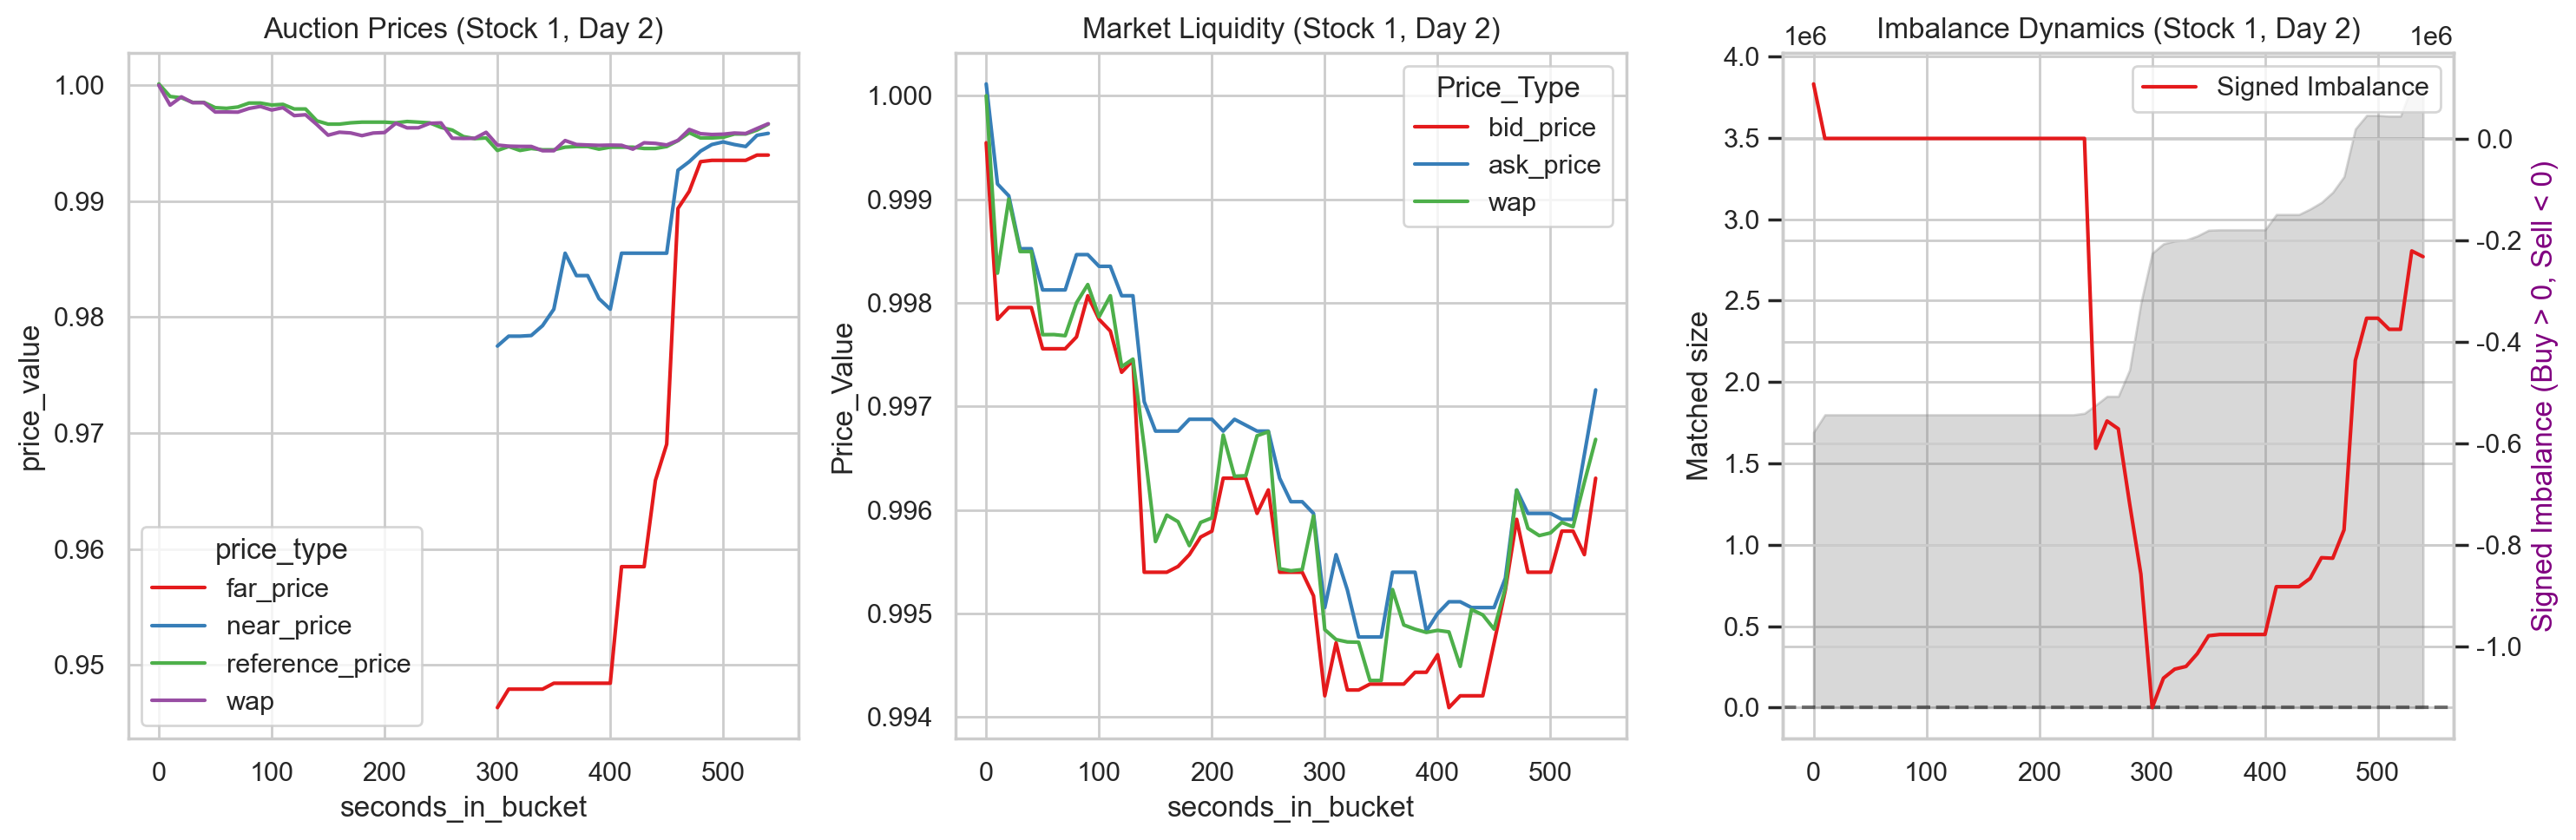

In [11]:
plot_stock(data, stock=1, date=2)

## metrics

MAE


## 字段说明
- 分布
- 统计：缺失、异常

- stock_id: 股票的唯一标识。
- date_id: 日期的唯一标识（按天递增）。
- seconds_in_bucket: 当前竞价时段内经过的秒数（从 0 开始，每 10 秒一行，最高到 540）。
- time_id / row_id: 唯一行标识。

竞价数据：反应供需
- imbalance_size: 以美元计量的未匹配金额。
- imbalance_buy_sell_flag: 失衡方向。1 代表买方失衡（买单多），-1 代表卖方失衡，0 代表平衡。
- matched_size: 当前参考价下可以匹配成交的金额（美元）。
- reference_price: 参考价格。它是使配对股份最大化、不平衡最小化的价格，通常被限制在最佳买卖价之间。
- far_price: 远端价格。仅基于竞价订单计算的模拟成交价（不含连续交易时段的订单）。
- near_price: 近端价格。结合了竞价订单和连续交易订单后的模拟成交价。

订单数据
- bid_price / ask_price: 订单簿中最优买入/卖出价（买一/卖一）。
- bid_size / ask_size: 最优买入/卖出位的美元金额。
- wap:成交量加权平均价（Weighted Average Price）


- target

数据是折叠后的，比如target，如果从查看角度，某个时刻 一些股票得target，这才是预测值，即预测得是一个target向量, 现在折叠起来 不好看了

因此我们对一个列空间进行统计分布，得到是 特征空间分布特征，无关哪个股票哪天得

In [12]:
def info_numeric_col(df, col):
    """ col列空间：统计、分布图、异常值图。
    """
    stat = pd.Series({
        'missing': df[col].isnull().sum(),
        'missing_percent': df[col].isnull().sum() / len(df[col]),
        'mean': df[col].mean(),
        'std':df[col].std(),
        'min': df[col].min(),
        '25%': df[col].quantile(0.25),
        'median': df[col].quantile(0.5),
        '75%': df[col].quantile(0.75),
        '99%': df[col].quantile(0.99), # 长尾
        'max': df[col].max(),
        'skewness': df[col].skew(), # 偏度
        'kurtosis': df[col].kurt() # 峰度
    })
    print(f"--- Statistics for {col} ---")    
    print(stat)
    fig, axes = plt.subplots(1,2, figsize=(8,4))
    
    sns.kdeplot(data=df, x=col, fill=True, ax=axes[0], color='red')
    axes[0].set_title(f'{col} distribution')

    sns.boxplot(data=df, x=col, ax= axes[1], color='green')
    axes[1].set_title(f'{col} outLiers')
    plt.tight_layout()
    plt.show()


In [13]:
data.isnull().sum()

stock_id                         0
date_id                          0
seconds_in_bucket                0
imbalance_size                 220
imbalance_buy_sell_flag          0
reference_price                220
matched_size                   220
far_price                  2894342
near_price                 2857180
bid_price                      220
bid_size                         0
ask_price                      220
ask_size                         0
wap                            220
target                          88
time_id                          0
row_id                           0
dtype: int64

### far_price，near_price,reference_price

--- Statistics for reference_price ---
missing            220.000000
missing_percent      0.000042
mean                 0.999996
std                  0.002532
min                  0.935285
25%                  0.998763
median               0.999967
75%                  1.001174
99%                  1.007185
max                  1.077488
skewness             0.396552
kurtosis            11.137140
dtype: float64


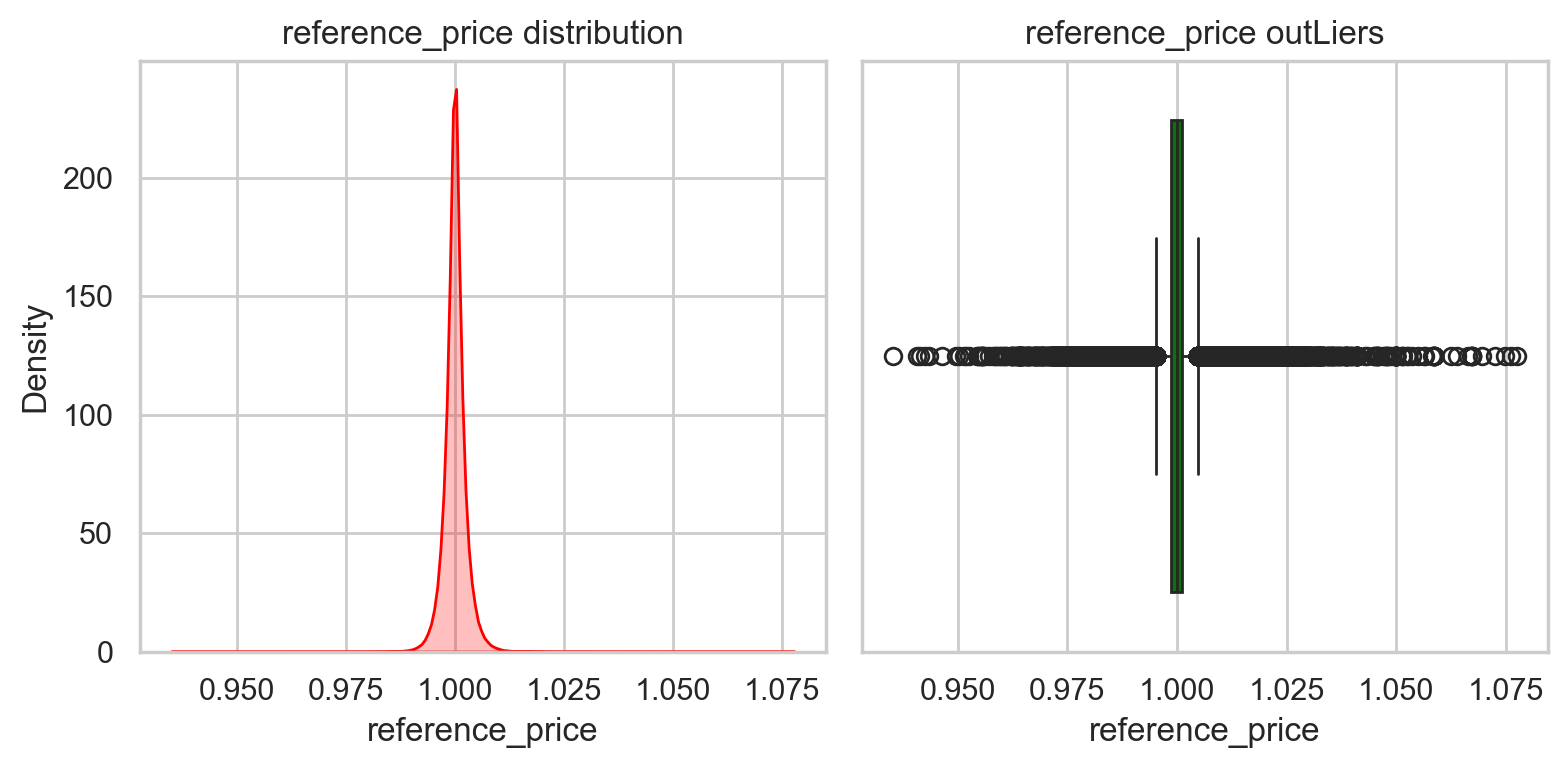

In [14]:
info_numeric_col(data, 'reference_price')

--- Statistics for far_price ---
missing            2.894342e+06
missing_percent    5.525684e-01
mean               1.001713e+00
std                7.214705e-01
min                7.700000e-05
25%                9.963320e-01
median             9.998830e-01
75%                1.003318e+00
99%                1.052688e+00
max                4.379531e+02
skewness           4.765590e+02
kurtosis           2.448905e+05
dtype: float64


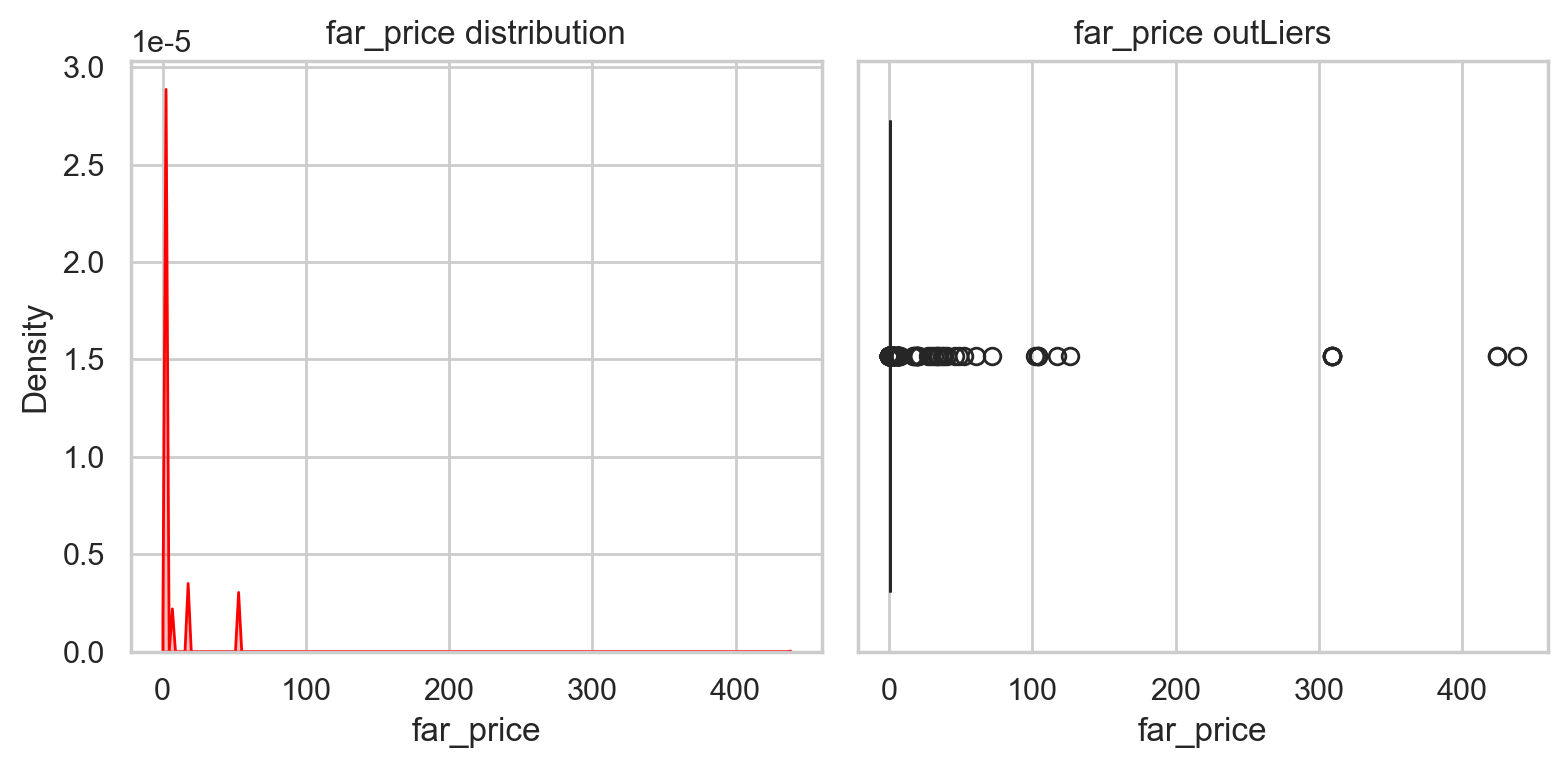

In [89]:
info_numeric_col(data, 'far_price')

缺失值过多，这里缺失本身是一个信号。 设置为0.

### imbalance_size,imbalance_buy_sell_flag,matched_size

--- Statistics for imbalance_size ---
missing            2.200000e+02
missing_percent    4.200092e-05
mean               5.715293e+06
std                2.051591e+07
min                0.000000e+00
25%                8.453415e+04
median             1.113604e+06
75%                4.190951e+06
99%                7.636496e+07
max                2.982028e+09
skewness           2.399480e+01
kurtosis           1.746991e+03
dtype: float64


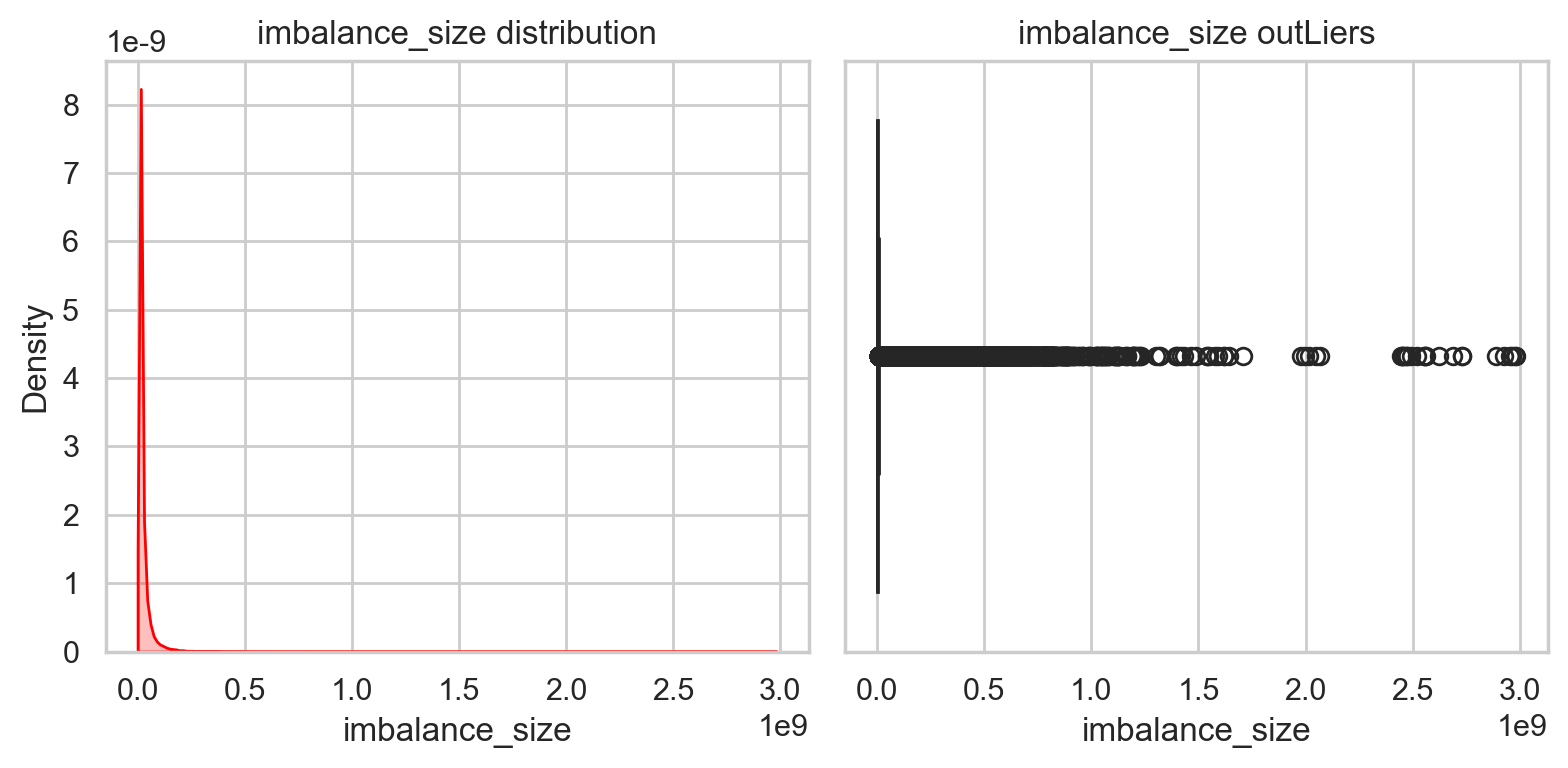

In [91]:
info_numeric_col(data, 'imbalance_size')

In [93]:
data['imbalance_buy_sell_flag'].value_counts()

imbalance_buy_sell_flag
-1    2084349
 1    2022037
 0    1131594
Name: count, dtype: int64

In [94]:
data['imbalance_buy_sell_flag'].isnull().sum()

0

--- Statistics for matched_size ---
missing            2.200000e+02
missing_percent    4.200092e-05
mean               4.510025e+07
std                1.398413e+08
min                4.316610e+03
25%                5.279575e+06
median             1.288264e+07
75%                3.270013e+07
99%                6.151657e+08
max                7.713682e+09
skewness           1.480903e+01
kurtosis           4.337253e+02
dtype: float64


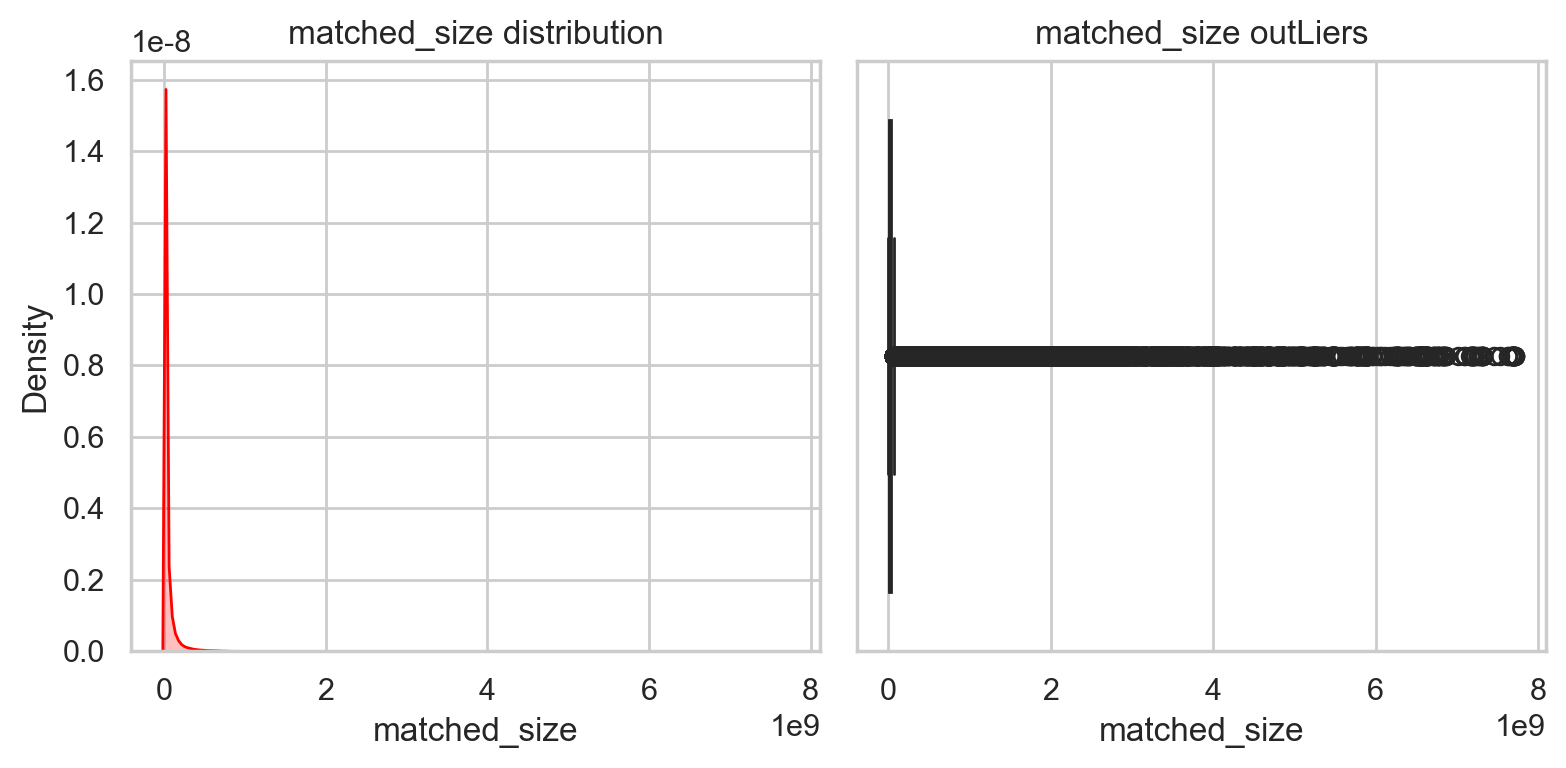

In [95]:
info_numeric_col(data, 'matched_size')

### bid_price, bid_size	,ask_price, ask_size, wap

In [ ]:
info_numeric_col(data,)

In [51]:
data[data[['bid_price', 'ask_price', 'wap']].isnull().all(axis=1)]


,stock_id,date_id,seconds_in_bucket,imbalance_size,imbalance_buy_sell_flag,reference_price,matched_size,far_price,near_price,bid_price,bid_size,ask_price,ask_size,wap,target,time_id,row_id
369508,131,35,0,NaN,0,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,1925,35_0_131
369700,131,35,10,NaN,0,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,1926,35_10_131
369892,131,35,20,NaN,0,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,1927,35_20_131
370084,131,35,30,NaN,0,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,1928,35_30_131
370276,131,35,40,NaN,0,NaN,NaN,NaN,NaN,NaN,0.00,NaN,0.00,NaN,NaN,1929,35_40_131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4774999,19,438,500,NaN,-1,NaN,NaN,NaN,NaN,NaN,115491.18,NaN,1990.10,NaN,3.319979,24140,438_500_19
4775199,19,438,510,NaN,-1,NaN,NaN,NaN,NaN,NaN,189040.50,NaN,26283.84,NaN,-5.049705,24141,438_510_19
4775399,19,438,520,NaN,-1,NaN,NaN,NaN,NaN,NaN,1392.93,NaN,43799.80,NaN,-0.110269,24142,438_520_19
4775599,19,438,530,NaN,-1,NaN,NaN,NaN,NaN,NaN,13531.32,NaN,26881.20,NaN,-1.689792,24143,438_530_19


可以删除这些行

--- Statistics for wap ---
missing            220.000000
missing_percent      0.000042
mean                 0.999992
std                  0.002498
min                  0.938008
25%                  0.998781
median               0.999997
75%                  1.001149
99%                  1.007088
max                  1.077675
skewness             0.375521
kurtosis            10.886225
dtype: float64


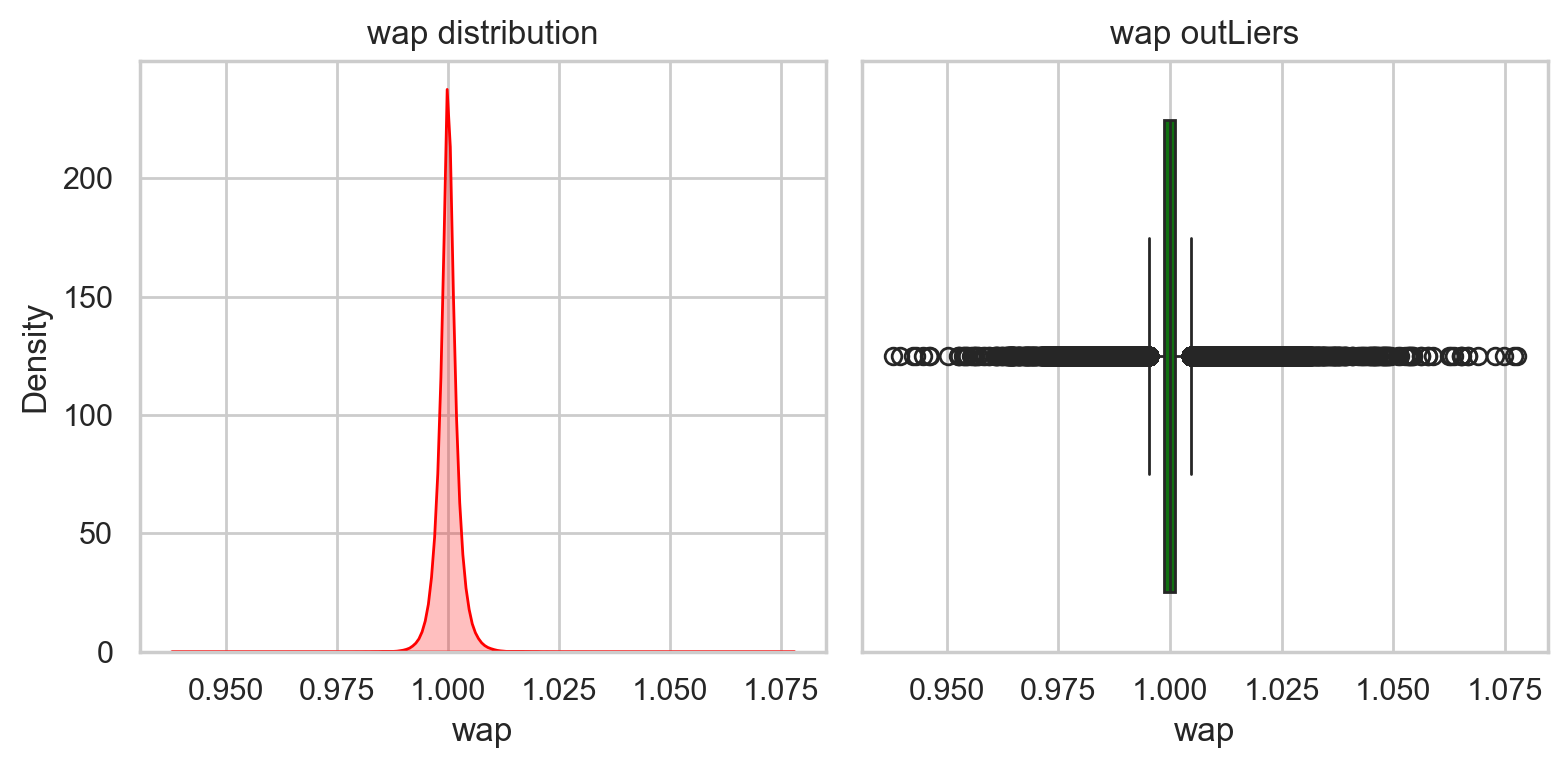

In [105]:
info_numeric_col(data, 'wap')

--- Statistics for bid_price ---
missing            220.000000
missing_percent      0.000042
mean                 0.999726
std                  0.002499
min                  0.934915
25%                  0.998529
median               0.999728
75%                  1.000905
99%                  1.006707
max                  1.077488
skewness             0.204360
kurtosis            10.457828
dtype: float64


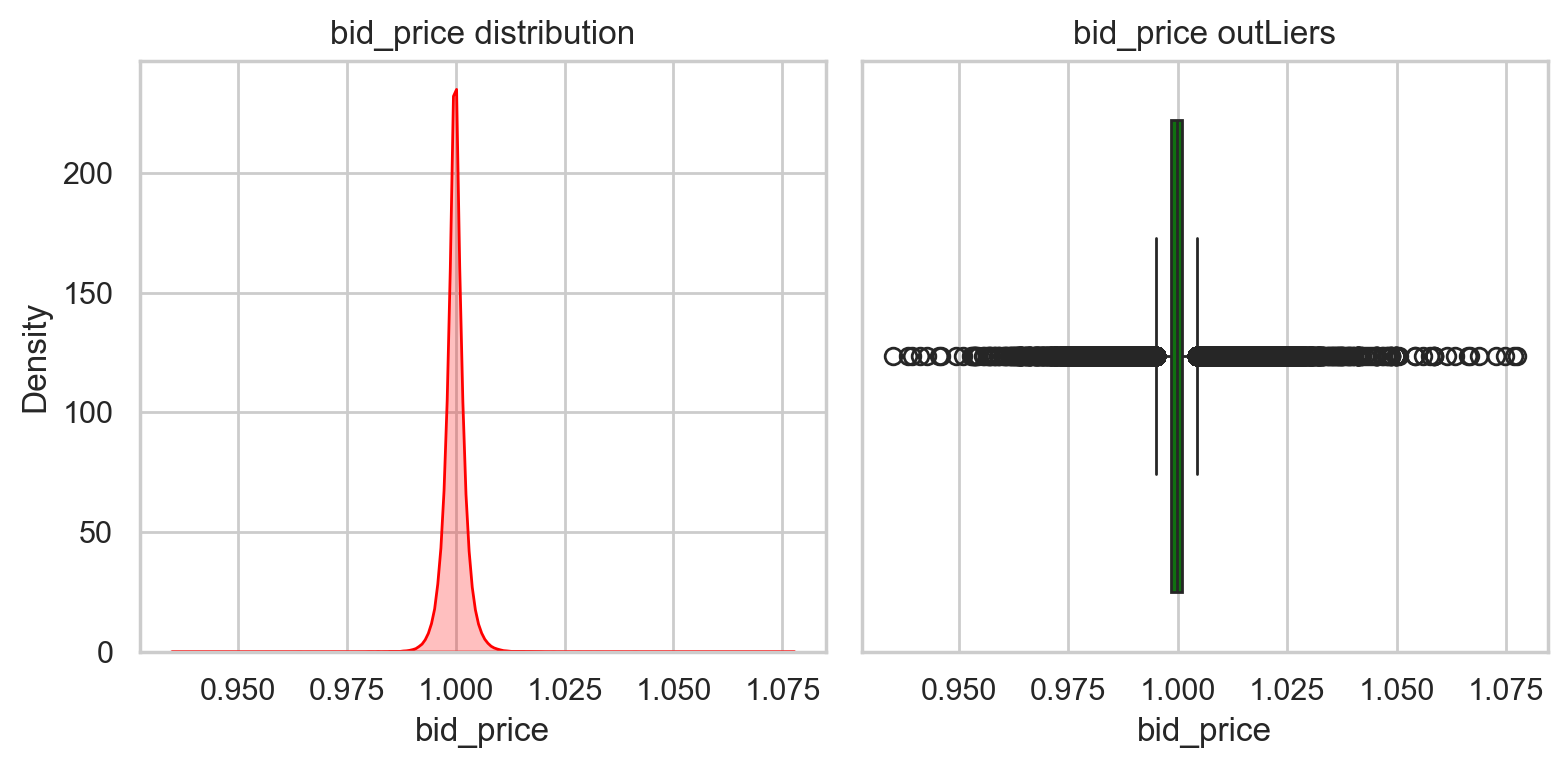

In [99]:
info_numeric_col(data, 'bid_price')

--- Statistics for ask_price ---
missing            220.000000
missing_percent      0.000042
mean                 1.000264
std                  0.002510
min                  0.939827
25%                  0.999029
median               1.000207
75%                  1.001414
99%                  1.007501
max                  1.077836
skewness             0.540173
kurtosis            11.469103
dtype: float64


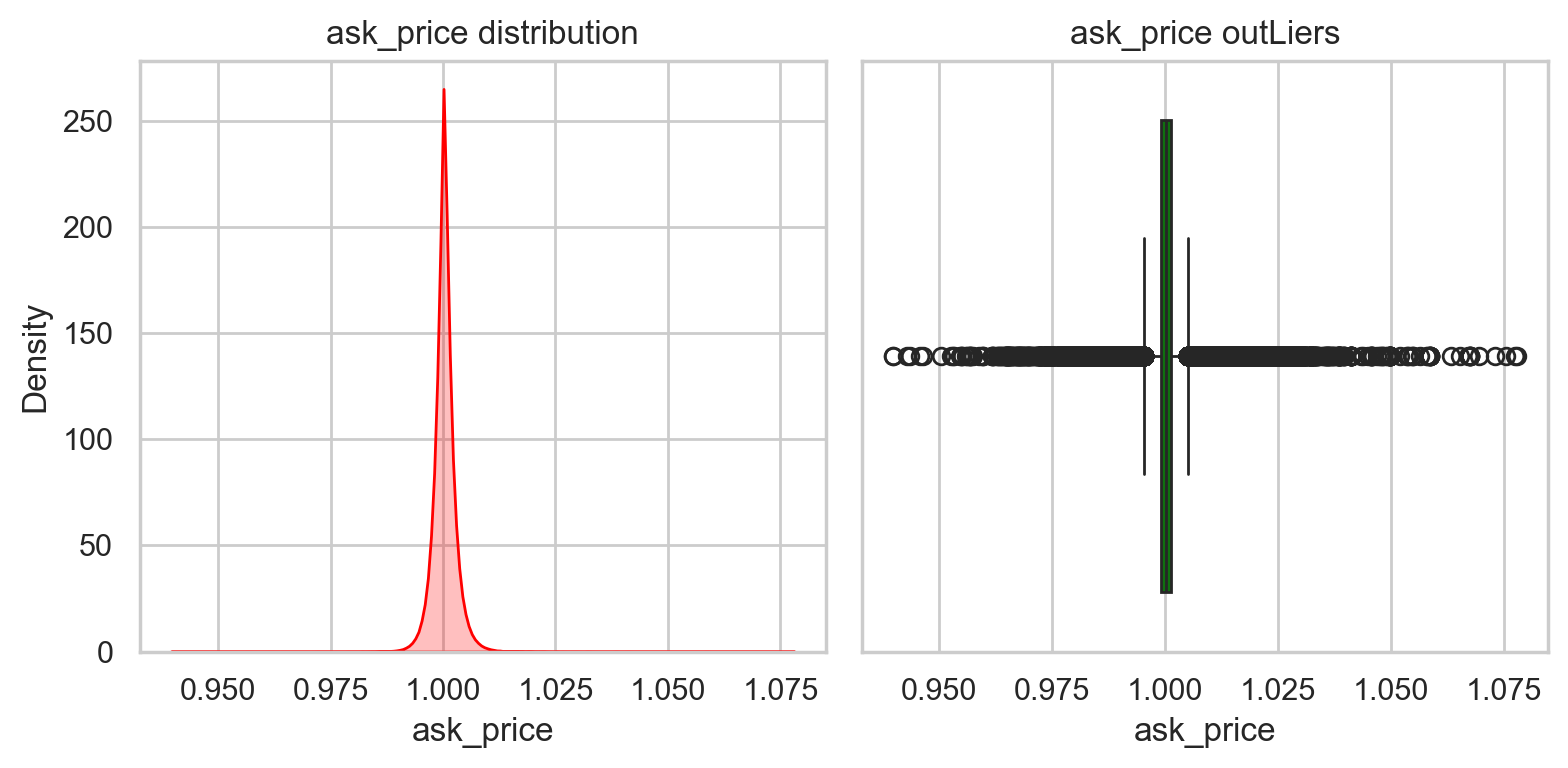

In [100]:
info_numeric_col(data, 'ask_price')

--- Statistics for imbalance_size ---
missing            2.200000e+02
missing_percent    4.200092e-05
mean               5.715293e+06
std                2.051591e+07
min                0.000000e+00
25%                8.453415e+04
median             1.113604e+06
75%                4.190951e+06
99%                7.636496e+07
max                2.982028e+09
skewness           2.399480e+01
kurtosis           1.746991e+03
dtype: float64


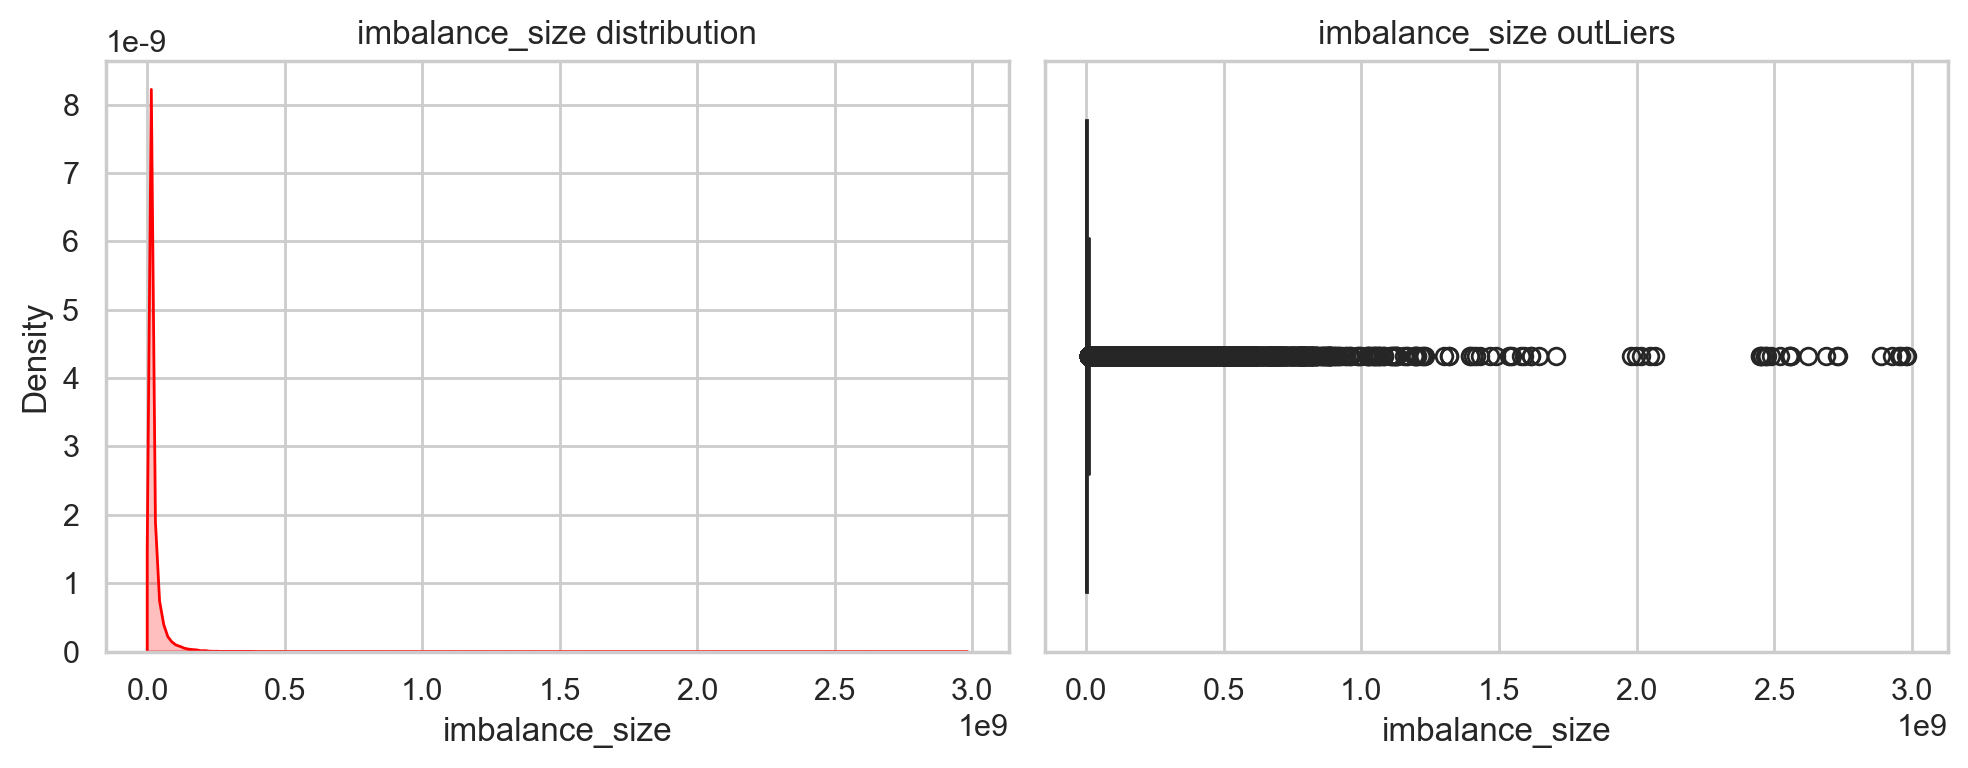

In [70]:
info_numeric_col(data, 'imbalance_size')

### target

--- Statistics for target ---
missing             88.000000
missing_percent      0.000017
mean                -0.047561
std                  9.452860
min               -385.289800
25%                 -4.559755
median              -0.060201
75%                  4.409552
99%                 25.990010
max                446.070430
skewness             0.204669
kurtosis            22.557970
dtype: float64


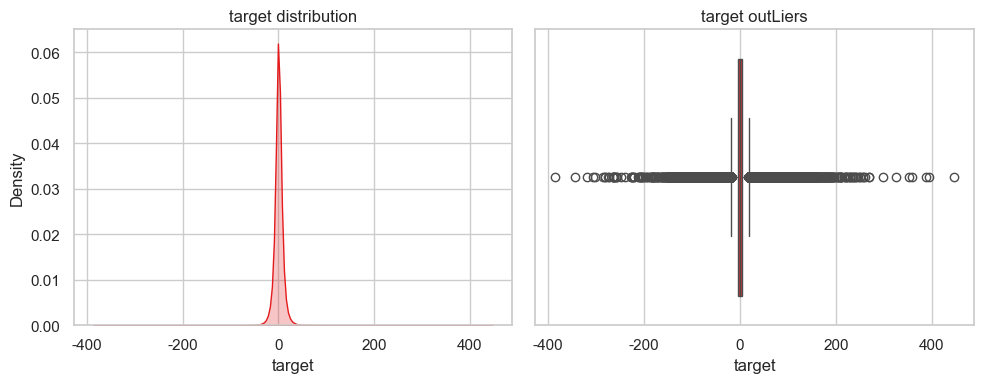

In [61]:
info_numeric_col(data, 'target')

`target`的分布是 **尖峰长尾**。 

### 处理
把上面的分析，处理一下

In [70]:
print(data.shape)
data = data.dropna(subset=['bid_price', 'ask_price', 'wap'], how='all')
print(data.shape)

(5237760, 17)
(5237760, 17)


In [56]:
data.isnull().sum()

stock_id                         0
date_id                          0
seconds_in_bucket                0
imbalance_size                   0
imbalance_buy_sell_flag          0
reference_price                  0
matched_size                     0
far_price                  2894122
near_price                 2856960
bid_price                        0
bid_size                         0
ask_price                        0
ask_size                         0
wap                              0
target                           0
time_id                          0
row_id                           0
dtype: int64

## baseline

$$
x_{stock, t} -> target_{stock, t} 
$$


- stock_id: 标准化后， 应该去掉。不应该对结果影响
- dateId: 同样的，不具备数值意义，也去掉

问题：
1. 标准化，按照公式，应该根据stock分组后，stock内进行标准化， 列再标准化？
2. 


In [39]:
data.isnull().sum()

stock_id                         0
date_id                          0
seconds_in_bucket                0
imbalance_size                 220
imbalance_buy_sell_flag          0
reference_price                220
matched_size                   220
far_price                  2894342
near_price                 2857180
bid_price                      220
bid_size                         0
ask_price                      220
ask_size                         0
wap                            220
target                          88
time_id                          0
row_id                           0
dtype: int64

In [71]:
y = data['target']
X = data.drop(columns=['target', 'stock_id', 'date_id', 'seconds_in_bucket', 'row_id', 'time_id'])

In [72]:
X.isnull().sum()

imbalance_size                   0
imbalance_buy_sell_flag          0
reference_price                  0
matched_size                     0
far_price                  2894122
near_price                 2856960
bid_price                        0
bid_size                         0
ask_price                        0
ask_size                         0
wap                              0
dtype: int64

In [73]:
X_train, X_test, y_train, y_test = train_test_split(X,y)

In [74]:
print(X_train.shape, X_test.shape)

(3928320, 11) (1309440, 11)


In [75]:
model  = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler()),
    ('ridge', Ridge())
])

In [76]:
model.fit(X,y)

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('ridge', Ridge())])

In [77]:
mean_absolute_error(y_test, model.predict(X_test))

6.314769828852861

In [84]:
from public_timeseries_testing_util import make_env

In [85]:
env = make_env()

In [86]:
counter = 0
for (test, revealed_targets, sample_prediction) in env.iter_test():
    sample_prediction['target'] = model.predict(test.drop(columns=[ 'stock_id', 'date_id', 'seconds_in_bucket', 'row_id', 'time_id']))
    env.predict(sample_prediction)
    counter += 1

FileNotFoundError: [Errno 2] No such file or directory: 'test.csv'